In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import stats
from pathlib import Path


In [10]:
# --- 1. AGE DATA DEFINITION ---
AGE_DATA = {
    '1005': 50.0, '1007': 31.0, '1014': 23.0, '1004': 33.0, '1020': 29.0,
    '1017': 46.0, '1016': 36.0, '1002': 43.0, '1023': 46.0, '1034': 60.0,
    '1008': 25.0, '1041': 49.0, '3011': 31.0, '1001': 25.0, '3005': 39.0,
    '1042': 39.0, '1039': 63.0, '2023': 49.0, '3007': 41.0, '3030': 54.0,
    '3016': 44.0, '3014': 34.0, '2020': 43.0, '1011': 37.0, '1024': 24.0,
    '3001': 54.0, '1038': 45.0, '2006': 25.0, '1021': 28.0, '2009': 49.0,
    '1010': 26.0, '3006': 33.0, '1046': 61.0, '2028': 29.0, '2026': 47.0,
    '2037': 45.0, '3027': 72.0, '1044': 62.0, '1028': 62.0, '3034': 48.0,
    '2017': 31.0, '1052': 53.0, '3039': 34.0, '3041': 35.0, '1026': 25.0,
    '1018': 25.0, '2029': 50.0, '2002': 62.0, '3008': 32.0,
}
# --- 1. SETUP ---
RESULTS_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/ECOC_Results")
PLOTS_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots")

# Load the distances we exported from File 1
df_dist = pd.read_csv(RESULTS_DIR / "Neural_Distances_for_Modeling.csv")

# Define Contrast Levels (X-axis)
CONTRASTS = np.array([5, 10, 50, 100])


In [11]:

# --- 2. THE NAKA-RUSHTON MODEL ---
def naka_rushton(c, Rmax, c50, n=2):
    """
    c: contrast level
    Rmax: maximum response
    c50: semi-saturation constant
    n: exponent (fixed at 2)
    """
    return Rmax * (c**n) / (c**n + c50**n)

# --- 3. THE FITTING FUNCTION ---
def fit_naka_rushton(df):
    results = []
    pathways = df['pathway'].unique()
    
    for p in pathways:
        p_df = df[df['pathway'] == p]
        
        for _, row in p_df.iterrows():
            # MATCHING THE NAMES FROM EXPORT: dist_5, dist_10, etc.
            y_data = np.array([row['dist_5'], row['dist_10'], row['dist_50'], row['dist_100']])
            
            try:
                # Initial guesses and bounds to prevent mathematical errors
                popt, _ = curve_fit(naka_rushton, CONTRASTS, y_data, 
                                   p0=[max(y_data), 25], 
                                   bounds=([0, 0.1], [5.0, 150]))
                
                rmax, c50 = popt
                results.append({
                    "subject": row['subject'],
                    "pathway": p,
                    "Rmax": rmax,
                    "C50": c50,
                    "peak_latency": row['peak_latency'],
                    "peak_accuracy": row['peak_accuracy']
                })
            except Exception as e:
                # If a specific subject fails, we skip them and keep going
                continue
                
    return pd.DataFrame(results)

# Run the fitting
df_params = fit_naka_rushton(df_dist)
df_params.to_csv(RESULTS_DIR / "Naka_Rushton_Parameters.csv", index=False)

print(f"✅ Success! Parameters saved for {len(df_params)} subject-pathway entries.")
print("The columns saved are: Rmax, C50, peak_latency, and peak_accuracy.")

✅ Success! Parameters saved for 147 subject-pathway entries.
The columns saved are: Rmax, C50, peak_latency, and peak_accuracy.


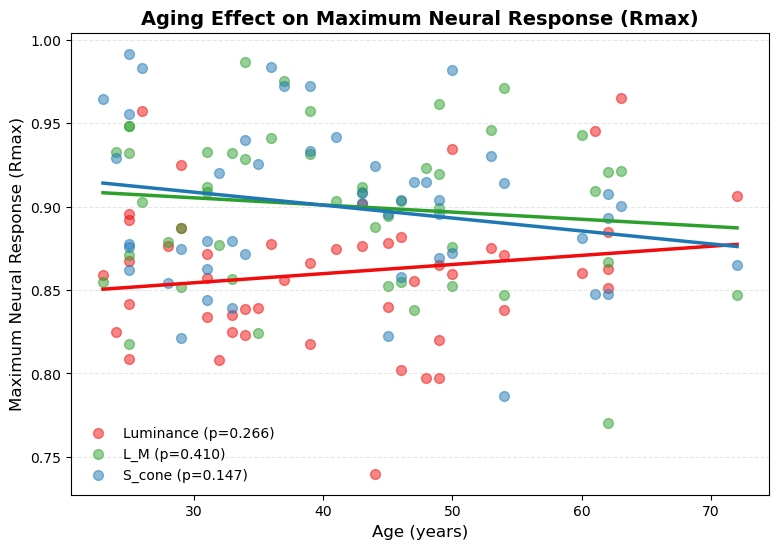

Regression plot saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/04_Aging_Rmax.png


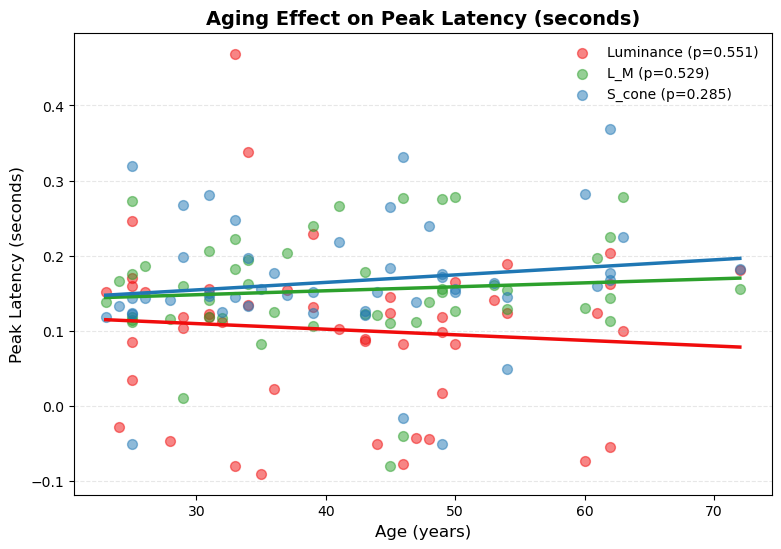

Regression plot saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/04_Aging_peak_latency.png


In [15]:
# Load fitted parameters
df_params = pd.read_csv(RESULTS_DIR / "Naka_Rushton_Parameters.csv")

# Extract numeric ID and map Age
df_params['subject_clean'] = df_params['subject'].astype(str).str.extract(r'(\d+)')
df_params['age'] = df_params['subject_clean'].map(AGE_DATA)
df_params = df_params.dropna(subset=['age'])

# Your specific colors
COLORS_MAP = {"Luminance": "#F00C0C", "L_M": "#2ca02c", "S_cone": "#1f77b4"}

# --- 3. REGRESSION PLOTTING FUNCTION ---
def plot_aging_effect(df, metric_name, ylabel):
    plt.figure(figsize=(9, 6))
    pathways = ["Luminance", "L_M", "S_cone"]
    
    for p in pathways:
        p_data = df[df['pathway'] == p]
        if p_data.empty: continue
        
        # Calculate Linear Regression
        slope, intercept, r_value, p_val, std_err = stats.linregress(p_data['age'], p_data[metric_name])
        
        # Scatter Points
        plt.scatter(p_data['age'], p_data[metric_name], color=COLORS_MAP[p], 
                    alpha=0.5, s=50, label=f"{p} (p={p_val:.3f})")
        
        # Regression Line
        x_range = np.array([p_data['age'].min(), p_data['age'].max()])
        plt.plot(x_range, slope * x_range + intercept, color=COLORS_MAP[p], linewidth=2.5)

    plt.title(f"Aging Effect on {ylabel}", fontsize=14, fontweight='bold')
    plt.xlabel("Age (years)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(frameon=False, loc='best')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    save_path = PLOTS_DIR / f"04_Aging_{metric_name}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Regression plot saved to: {save_path}")

# --- 4. EXECUTE PLOTS ---
plot_aging_effect(df_params, "Rmax", "Maximum Neural Response (Rmax)")
plot_aging_effect(df_params, "peak_latency", "Peak Latency (seconds)")

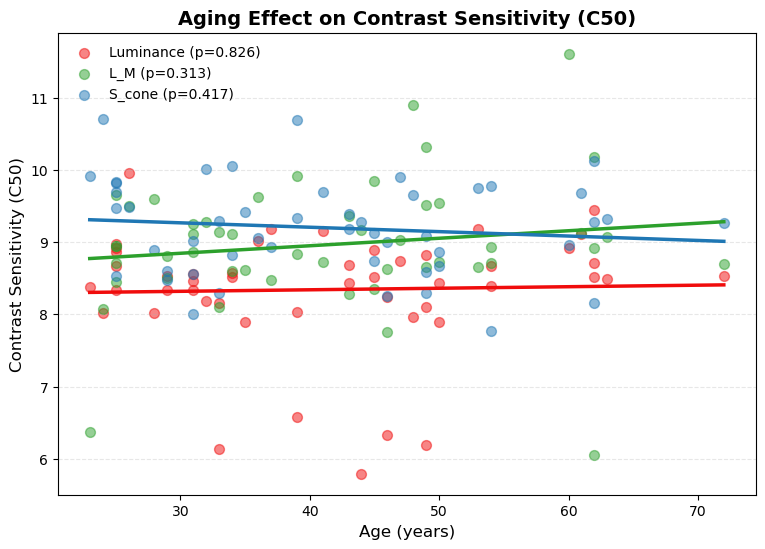

Regression plot saved to: /Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots/04_Aging_C50.png


In [16]:
# --- 5. EXECUTE C50 PLOT ---
# Plot C50 (Sensitivity) vs Age
# Note: Lower C50 generally means higher sensitivity to contrast.
plot_aging_effect(df_params, "C50", "Contrast Sensitivity (C50)")

In [17]:
# --- 6. MASTER STATISTICAL SUMMARY ---

def generate_stats_summary(df):
    metrics = ["Rmax", "C50", "peak_latency"]
    pathways = ["Luminance", "L_M", "S_cone"]
    summary_list = []

    for p in pathways:
        for m in metrics:
            p_data = df[df['pathway'] == p]
            if p_data.empty: continue
            
            # Perform Linear Regression
            slope, intercept, r_val, p_val, std_err = stats.linregress(p_data['age'], p_data[m])
            
            summary_list.append({
                "Pathway": p,
                "Metric": m,
                "Slope (per year)": round(slope, 5),
                "R-value": round(r_val, 3),
                "P-value": round(p_val, 4),
                "Significance": "*" if p_val < 0.05 else "ns"
            })
            
    # Create and display the DataFrame
    summary_df = pd.DataFrame(summary_list)
    
    # Save to your results folder
    summary_df.to_csv(RESULTS_DIR / "Aging_Statistical_Summary.csv", index=False)
    
    return summary_df

# Generate and display the final summary
stats_table = generate_stats_summary(df_params)
print("\n--- MASTER AGING STATISTICAL SUMMARY ---")
display(stats_table)


--- MASTER AGING STATISTICAL SUMMARY ---


,Pathway,Metric,Slope (per year),R-value,P-value,Significance
0,Luminance,Rmax,0.00055,0.162,0.2659,ns
1,Luminance,C50,0.00212,0.032,0.8262,ns
2,Luminance,peak_latency,-0.00074,-0.087,0.5512,ns
3,L_M,Rmax,-0.00043,-0.120,0.4103,ns
4,L_M,C50,0.01040,0.147,0.3131,ns
5,L_M,peak_latency,0.00053,0.092,0.5288,ns
6,S_cone,Rmax,-0.00078,-0.210,0.1466,ns
7,S_cone,C50,-0.00610,-0.118,0.4175,ns
8,S_cone,peak_latency,0.00100,0.156,0.2846,ns


/var/folders/_t/52p8xpgs1gdctzqmjjcqm0zm0000gn/T/ipykernel_2115/1569559289.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tidy, x="pathway_label", y="peak_latency", order=order,


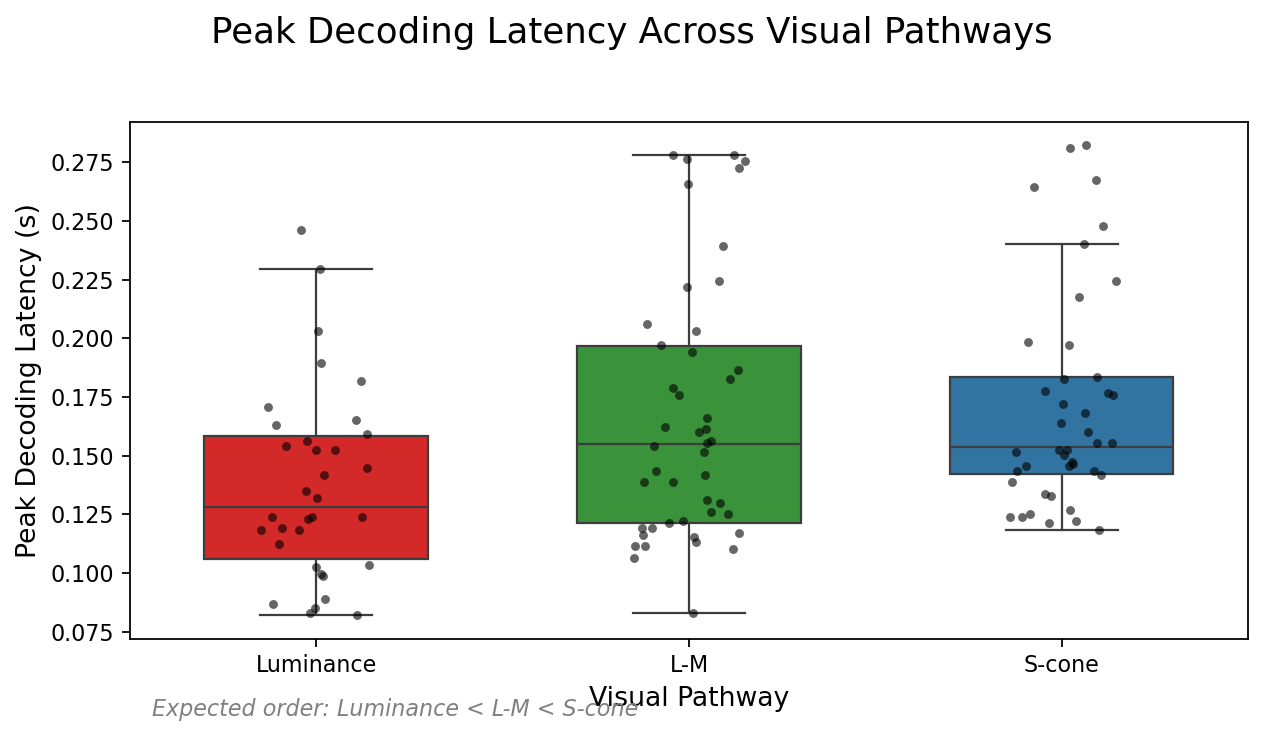

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. PREPARE TIDY DATAFRAME ---
# We use the parameters dataframe which already has age-matched subjects
df_tidy = df_params[['pathway', 'peak_latency']].copy()

# Rename pathways for the plot labels if necessary
path_map = {"Luminance": "Luminance", "L_M": "L-M", "S_cone": "S-cone"}
df_tidy['pathway_label'] = df_tidy['pathway'].map(path_map)

# Filter outliers based on your specific range (80ms to 300ms)
MIN_PEAK, MAX_PEAK = 0.08, 0.30 
df_tidy = df_tidy[df_tidy["peak_latency"].between(MIN_PEAK, MAX_PEAK)]

# --- 2. PLOT ---
order = ["Luminance", "L-M", "S-cone"]
# Map your custom colors to the new labels
PLOT_COLORS = {"Luminance": "#F00C0C", "L-M": "#2ca02c", "S-cone": "#1f77b4"}

fig, ax = plt.subplots(figsize=(8, 5), dpi=160)

# Boxplot for the distribution summary
sns.boxplot(data=df_tidy, x="pathway_label", y="peak_latency", order=order, 
            palette=PLOT_COLORS, fliersize=0, width=0.6, ax=ax, zorder=1)

# Stripplot for individual subject dots
sns.stripplot(data=df_tidy, x="pathway_label", y="peak_latency", order=order, 
              jitter=0.15, size=4, alpha=0.6, color="black", ax=ax, zorder=2)

# Formatting
ax.set_xlabel("Visual Pathway", fontsize=12)
ax.set_ylabel("Peak Decoding Latency (s)", fontsize=12)
fig.suptitle("Peak Decoding Latency Across Visual Pathways", fontsize=16, y=0.98)

# Add the descriptive text at the bottom
ax.text(0.02, -0.15, "Expected order: Luminance < L-M < S-cone", 
        transform=ax.transAxes, fontsize=10, style="italic", color="gray")

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Save the plot
plt.savefig(PLOTS_DIR / "05_Latency_Comparison_Boxplot.png", dpi=300)
plt.show()

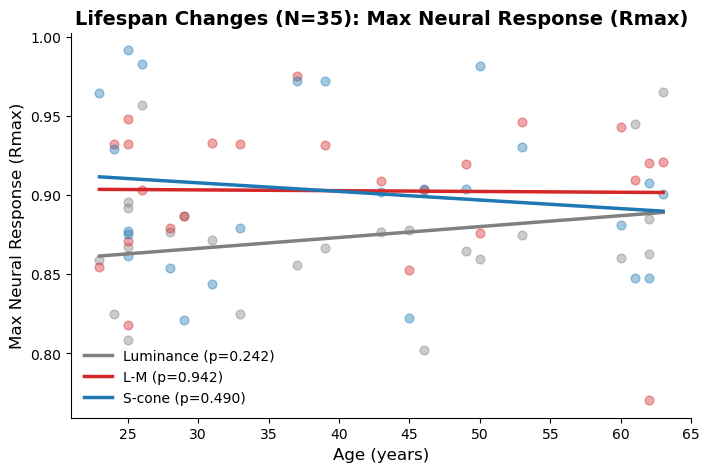

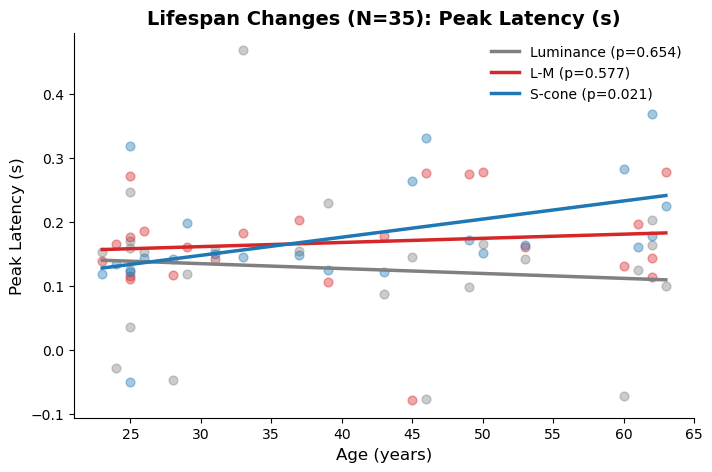

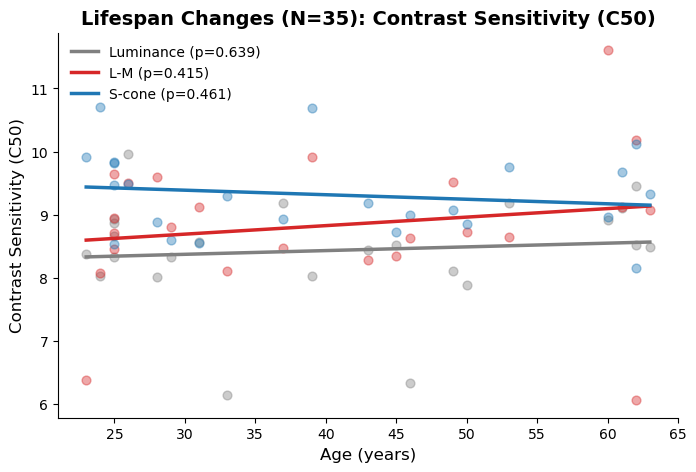

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# --- 1. SETTINGS & SUBJECT FILTER ---
RESULTS_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/ECOC_Results")
PLOTS_DIR = Path("/Users/farjam/OneDrive - University of Edinburgh/wellcome/Amir/Final_VEP/Plots")

# Your specific list of 35 subjects
ALLOWED_SUBJECTS = {
    '1001', '1002', '1004', '1005', '1007', '1008', '1010', '1011', '1014', '1015',
    '1018', '1020', '1021', '1022', '1023', '1024', '1026', '1028', '1029', '1031',
    '1033', '1034', '1037', '1038', '1039', '1041', '1042', '1044', '1046', '1049',
    '1050', '1052', '1057', '1059', '1064'
}

# Your requested color scheme
COLORS = {
    "Luminance": "#808080",  # Dark Gray
    "L_M":       "#D62728",  # Red
    "S_cone":    "#1F77B4",  # Blue
}

# --- 2. RELOAD & FILTER DATA ---
df_all = pd.read_csv(RESULTS_DIR / "Naka_Rushton_Parameters.csv")
df_all['subject_clean'] = df_all['subject'].astype(str).str.extract(r'(\d+)')

# Filter for the 35 subjects and map age
df_35 = df_all[df_all['subject_clean'].isin(ALLOWED_SUBJECTS)].copy()
df_35['age'] = df_35['subject_clean'].map(AGE_DATA)
df_35 = df_35.dropna(subset=['age'])

# --- 3. UPDATED PLOTTING FUNCTION ---
def plot_35_aging_final(df, metric, ylabel, filename):
    plt.figure(figsize=(8, 5))
    
    # We use the list to ensure the order in the legend is consistent
    for p in ["Luminance", "L_M", "S_cone"]:
        p_data = df[df['pathway'] == p]
        if p_data.empty: continue
        
        # Linear Regression
        slope, intercept, r_val, p_val, std_err = stats.linregress(p_data['age'], p_data[metric])
        
        # Use the specific color from your COLORS dictionary
        current_color = COLORS[p]
        
        # Plot Scatter Points
        plt.scatter(p_data['age'], p_data[metric], color=current_color, alpha=0.4, s=40)
        
        # Plot Regression Line
        x_range = np.array([p_data['age'].min(), p_data['age'].max()])
        plt.plot(x_range, slope * x_range + intercept, color=current_color, 
                 linewidth=2.5, label=f"{p.replace('_','-')} (p={p_val:.3f})")

    plt.title(f"Lifespan Changes (N=35): {ylabel}", fontsize=14, fontweight='bold')
    plt.xlabel("Age (years)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(frameon=False, loc='best')
    
    # Clean up spines for a scientific look
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    
    plt.savefig(PLOTS_DIR / f"Final_35_{filename}", dpi=300, bbox_inches='tight')
    plt.show()

# --- 4. EXECUTE ---
plot_35_aging_final(df_35, "Rmax", "Max Neural Response (Rmax)", "Aging_Rmax.png")
plot_35_aging_final(df_35, "peak_latency", "Peak Latency (s)", "Aging_Latency.png")
plot_35_aging_final(df_35, "C50", "Contrast Sensitivity (C50)", "Aging_C50.png")